# 🚗 Car Damage Detector — PyTorch Custom Model
**Ketma-ketlik:** Har bir katakni yuqoridan pastga ishlatib boring. Hammasi 1 faylda!

In [3]:
!pip install -q torch torchvision albumentations opencv-python-headless matplotlib tqdm
import torch
print(f'✅ PyTorch: {torch.__version__}')
print(f'✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "YOQ — Runtime > GPU ni yoqing"}')
print(f'✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')

✅ PyTorch: 2.11.0+cu128
✅ GPU: Tesla T4
✅ VRAM: 15.6 GB


In [4]:
from google.colab import files
import zipfile, os

print('📁 final_yolo_dataset.zip faylni tanlang...')
uploaded = files.upload()

ZIP_NAME = list(uploaded.keys())[0]
DATASET_PATH = '/content/dataset'

with zipfile.ZipFile(ZIP_NAME, 'r') as z:
    z.extractall(DATASET_PATH)

# Fayl sonlarini tekshirish
for split in ['train', 'val', 'test']:
    imgs = len(os.listdir(f'{DATASET_PATH}/images/{split}'))
    lbls = len(os.listdir(f'{DATASET_PATH}/labels/{split}'))
    print(f'✅ {split}: {imgs} rasm, {lbls} label')

📁 final_yolo_dataset.zip faylni tanlang...


Saving final_yolo_dataset.zip to final_yolo_dataset.zip
✅ train: 4244 rasm, 4244 label
✅ val: 909 rasm, 909 label
✅ test: 910 rasm, 910 label


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2, os, numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

CLASS_NAMES = ['dent', 'scratch', 'damage']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 640

def yolo_to_xyxy(box, w, h):
    cx, cy, bw, bh = box
    x1 = (cx - bw/2) * w
    y1 = (cy - bh/2) * h
    x2 = (cx + bw/2) * w
    y2 = (cy + bh/2) * h
    return [x1, y1, x2, y2]

class CarDamageDataset(Dataset):
    def __init__(self, root, split='train', img_size=640, augment=False):
        self.img_dir  = os.path.join(root, 'images', split)
        self.lbl_dir  = os.path.join(root, 'labels', split)
        self.img_size = img_size
        self.augment  = augment
        self.imgs = sorted([f for f in os.listdir(self.img_dir)
                            if f.lower().endswith(('.jpg','.jpeg','.png'))])

        self.aug = A.Compose([
            A.RandomResizedCrop(size=(img_size, img_size), scale=(0.3, 1.0)),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
            A.RandomRotate90(p=0.3),
            A.GaussNoise(p=0.3),
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.3))

        self.val_tf = A.Compose([
            A.Resize(height=img_size, width=img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        lbl_path = os.path.join(self.lbl_dir,
                                os.path.splitext(self.imgs[idx])[0] + '.txt')

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        boxes, labels = [], []
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls  = int(parts[0])
                        box  = [float(x) for x in parts[1:5]]
                        xyxy = yolo_to_xyxy(box, w, h)
                        xyxy = [max(0, xyxy[0]), max(0, xyxy[1]),
                                min(w, xyxy[2]), min(h, xyxy[3])]
                        if xyxy[2] > xyxy[0] and xyxy[3] > xyxy[1]:
                            boxes.append(xyxy)
                            labels.append(cls)

        if not boxes:
            boxes  = [[0, 0, 1, 1]]
            labels = [0]

        tf     = self.aug if self.augment else self.val_tf
        result = tf(image=img, bboxes=boxes, labels=labels)
        image  = result['image']
        boxes  = torch.tensor(result['bboxes'], dtype=torch.float32) if result['bboxes'] else torch.zeros((0,4))
        labels = torch.tensor(result['labels'], dtype=torch.long)    if result['labels'] else torch.zeros(0, dtype=torch.long)

        return image, {'boxes': boxes, 'labels': labels}

def collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)

DATASET_PATH = '/content/dataset'
train_ds = CarDamageDataset(DATASET_PATH, 'train', IMG_SIZE, augment=True)
val_ds   = CarDamageDataset(DATASET_PATH, 'val',   IMG_SIZE, augment=False)
train_dl = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=True)
print(f'✅ Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'✅ Train batches: {len(train_dl)} | Val batches: {len(val_dl)}')

✅ Train: 4244 | Val: 909
✅ Train batches: 1061 | Val batches: 228


/tmp/ipykernel_998/2131940461.py:38: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.SiLU() if act else nn.Identity()
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class DepthwiseSep(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, mid), nn.SiLU(),
            nn.Linear(mid, channels), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(self.pool(x)).view(x.shape[0], -1, 1, 1)

class ResBlock(nn.Module):
    def __init__(self, ch, expansion=2):
        super().__init__()
        mid = ch * expansion
        self.net = nn.Sequential(
            ConvBNAct(ch, mid, k=1, p=0),
            DepthwiseSep(mid, mid),
            SEBlock(mid),
            ConvBNAct(mid, ch, k=1, p=0, act=False)
        )
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))

class Stage(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks):
        super().__init__()
        self.down   = ConvBNAct(in_ch, out_ch, k=3, s=2)
        self.blocks = nn.Sequential(*[ResBlock(out_ch) for _ in range(n_blocks)])
    def forward(self, x):
        return self.blocks(self.down(x))

# ---- Kichraytirilgan Backbone ----
class CustomBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3,  16, k=3, s=2),
            ConvBNAct(16, 32, k=3, s=1),
        )
        self.stage1 = Stage(32,  64,  2)
        self.stage2 = Stage(64,  128, 3)   # -> C3
        self.stage3 = Stage(128, 256, 4)   # -> C4
        self.stage4 = Stage(256, 512, 2)   # -> C5
    def forward(self, x):
        x  = self.stem(x)
        x  = self.stage1(x)
        c3 = self.stage2(x)
        c4 = self.stage3(c3)
        c5 = self.stage4(c4)
        return c3, c4, c5

class FPN(nn.Module):
    def __init__(self, in_channels=(128, 256, 512), out_ch=128):
        super().__init__()
        c3, c4, c5 = in_channels
        self.lat5 = ConvBNAct(c5, out_ch, k=1, p=0)
        self.lat4 = ConvBNAct(c4, out_ch, k=1, p=0)
        self.lat3 = ConvBNAct(c3, out_ch, k=1, p=0)
        self.out5 = ConvBNAct(out_ch, out_ch, k=3)
        self.out4 = ConvBNAct(out_ch, out_ch, k=3)
        self.out3 = ConvBNAct(out_ch, out_ch, k=3)
        self.pan4 = ConvBNAct(out_ch, out_ch, k=3, s=2)
        self.pan5 = ConvBNAct(out_ch, out_ch, k=3, s=2)
    def forward(self, c3, c4, c5):
        p5 = self.lat5(c5)
        p4 = self.lat4(c4) + F.interpolate(p5, scale_factor=2, mode='nearest')
        p3 = self.lat3(c3) + F.interpolate(p4, scale_factor=2, mode='nearest')
        p3 = self.out3(p3)
        p4 = self.out4(p4)
        p5 = self.out5(p5)
        p4 = p4 + self.pan4(p3)
        p5 = p5 + self.pan5(p4)
        return p3, p4, p5

class DetHead(nn.Module):
    def __init__(self, in_ch=128, num_classes=3, num_anchors=3):
        super().__init__()
        out = num_anchors * (5 + num_classes)
        self.head = nn.Sequential(
            ConvBNAct(in_ch, in_ch, k=3),
            ConvBNAct(in_ch, in_ch, k=3),
            nn.Conv2d(in_ch, out, 1)
        )
    def forward(self, x):
        return self.head(x)

class CarDamageDetector(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = CustomBackbone()
        self.neck     = FPN((128, 256, 512), out_ch=128)
        self.head3    = DetHead(128, num_classes, num_anchors=3)
        self.head4    = DetHead(128, num_classes, num_anchors=3)
        self.head5    = DetHead(128, num_classes, num_anchors=3)
    def forward(self, x):
        c3, c4, c5 = self.backbone(x)
        p3, p4, p5 = self.neck(c3, c4, c5)
        return self.head3(p3), self.head4(p4), self.head5(p5)

# Tekshirish
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = CarDamageDetector(NUM_CLASSES).to(device)

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    o3, o4, o5 = model(dummy)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'✅ Model ishlaydi!')
print(f'   P3: {tuple(o3.shape)}')
print(f'   P4: {tuple(o4.shape)}')
print(f'   P5: {tuple(o5.shape)}')
print(f'   Parametrlar: {total_params:.1f}M')

✅ Model ishlaydi!
   P3: (2, 24, 80, 80)
   P4: (2, 24, 40, 40)
   P5: (2, 24, 20, 20)
   Parametrlar: 10.6M


In [7]:
import torch, torch.nn as nn, torch.nn.functional as F

ANCHORS = [
    # P3 — kichik (80x80 grid)
    [(10,13),(16,30),(33,23)],
    # P4 — o'rta (40x40)
    [(30,61),(62,45),(59,119)],
    # P5 — katta (20x20)
    [(116,90),(156,198),(373,326)],
]
STRIDES = [8, 16, 32]   # 640/80, 640/40, 640/20


def compute_iou(box1, box2):
    """box1, box2: [..., 4] formatida xyxy"""
    x1 = torch.max(box1[..., 0], box2[..., 0])
    y1 = torch.max(box1[..., 1], box2[..., 1])
    x2 = torch.min(box1[..., 2], box2[..., 2])
    y2 = torch.min(box1[..., 3], box2[..., 3])
    inter = (x2-x1).clamp(0) * (y2-y1).clamp(0)
    a1 = (box1[...,2]-box1[...,0]) * (box1[...,3]-box1[...,1])
    a2 = (box2[...,2]-box2[...,0]) * (box2[...,3]-box2[...,1])
    return inter / (a1 + a2 - inter + 1e-6)


class YOLOLoss(nn.Module):
    def __init__(self, num_classes=3, anchors=ANCHORS, strides=STRIDES, img_size=640):
        super().__init__()
        self.nc       = num_classes
        self.anchors  = anchors
        self.strides  = strides
        self.img_size = img_size
        self.bce      = nn.BCEWithLogitsLoss()
        self.mse      = nn.MSELoss()

    def forward(self, preds, targets):
        """
        preds: (out3, out4, out5)
        targets: list of dicts {'boxes': [N,4], 'labels': [N]}
        """
        total_loss = torch.tensor(0.0, device=preds[0].device, requires_grad=True)
        loss_box, loss_obj, loss_cls = 0.0, 0.0, 0.0

        for scale_idx, (pred, anch, stride) in enumerate(zip(preds, self.anchors, self.strides)):
            B, C, H, W = pred.shape
            na = len(anch)              # anchor soni = 3
            pred = pred.view(B, na, 5 + self.nc, H, W).permute(0,1,3,4,2)
            # pred: [B, 3, H, W, 5+nc]

            obj_target  = torch.zeros(B, na, H, W,          device=pred.device)
            box_target  = torch.zeros(B, na, H, W, 4,       device=pred.device)
            cls_target  = torch.zeros(B, na, H, W, self.nc, device=pred.device)
            obj_mask    = torch.zeros(B, na, H, W,          dtype=torch.bool, device=pred.device)

            anch_t = torch.tensor(anch, dtype=torch.float32, device=pred.device) / stride

            for bi, target in enumerate(targets):
                boxes  = target['boxes']
                labels = target['labels']
                if boxes.numel() == 0:
                    continue
                boxes = boxes.to(pred.device)
                labels = labels.to(pred.device)

                # Normalize qilish
                gxy = ((boxes[:, :2] + boxes[:, 2:]) / 2) / (stride * W / W)
                gwh = (boxes[:, 2:] - boxes[:, :2]) / stride
                gxy = gxy / W * W   # grid koordinatalar

                cx = (gxy[:, 0] / (self.img_size / W)).clamp(0, W-1).long()
                cy = (gxy[:, 1] / (self.img_size / H)).clamp(0, H-1).long()

                # Eng yaxshi anchor topish
                for gi, (gx, gy, gw, gh, cls) in enumerate(zip(cx, cy, gwh[:,0], gwh[:,1], labels)):
                    # Anchor bilan IoU
                    anch_ious = torch.min(anch_t[:,0], gw) * torch.min(anch_t[:,1], gh) / \
                                (anch_t[:,0]*anch_t[:,1] + gw*gh - torch.min(anch_t[:,0],gw)*torch.min(anch_t[:,1],gh) + 1e-6)
                    best_a = anch_ious.argmax()

                    obj_mask[bi, best_a, gy, gx]    = True
                    obj_target[bi, best_a, gy, gx]  = 1.0
                    box_target[bi, best_a, gy, gx]  = torch.stack([
                        gxy[gi,0]/(self.img_size/W) - gx.float(),
                        gxy[gi,1]/(self.img_size/H) - gy.float(),
                        torch.log(gw / anch_t[best_a,0] + 1e-6),
                        torch.log(gh / anch_t[best_a,1] + 1e-6)
                    ])
                    cls_idx = cls.long().clamp(0, self.nc-1)
                    cls_target[bi, best_a, gy, gx, cls_idx] = 1.0

            # Loss hisoblash
            loss_obj += self.bce(pred[..., 4], obj_target)
            if obj_mask.any():
                loss_box += self.mse(pred[obj_mask][..., :4], box_target[obj_mask])
                loss_cls += self.bce(pred[obj_mask][..., 5:], cls_target[obj_mask])

        total = 7.5 * loss_obj + 0.5 * loss_box + 0.5 * loss_cls
        return total, loss_box, loss_obj, loss_cls


criterion = YOLOLoss(NUM_CLASSES)
print('✅ Loss funksiyasi tayyor!')

✅ Loss funksiyasi tayyor!


In [8]:
import torch, os, gc
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

gc.collect()
torch.cuda.empty_cache()
print(f"VRAM bo'sh: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB")

EPOCHS   = 30
LR       = 1e-3
SAVE_DIR = '/content/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
history = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss = 0.0
    bar = tqdm(train_dl, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=False)

    for imgs, targets in bar:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss, lb, lo, lc = criterion(preds, targets)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        bar.set_postfix(loss=f'{loss.item():.3f}', box=f'{lb:.3f}', obj=f'{lo:.3f}', cls=f'{lc:.3f}')

    train_loss /= len(train_dl)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in tqdm(val_dl, desc=f'Epoch {epoch}/{EPOCHS} [Val]', leave=False):
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss, _, _, _ = criterion(preds, targets)
            val_loss += loss.item()
    val_loss /= len(val_dl)

    scheduler.step()
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f'Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_loss': val_loss,
        }, f'{SAVE_DIR}/best_model.pt')
        print(f'  💾 Saqlandi! Val loss: {val_loss:.4f}')

print(f'\n✅ O\'qitish tugadi! Eng yaxshi val loss: {best_val_loss:.4f}')

VRAM bo'sh: 15.57 GB


Epoch   1/30 | Train: 1.4062 | Val: 2.5119 | LR: 9.97e-04
  💾 Saqlandi! Val loss: 2.5119


Epoch   2/30 | Train: 0.5993 | Val: 2.2281 | LR: 9.89e-04
  💾 Saqlandi! Val loss: 2.2281


Epoch   3/30 | Train: 0.5861 | Val: 2.1798 | LR: 9.76e-04
  💾 Saqlandi! Val loss: 2.1798


Epoch   4/30 | Train: 0.5722 | Val: 2.3326 | LR: 9.57e-04


...

Epoch  26/30 | Train: 0.5413 | Val: 2.1796 | LR: 4.42e-05


Epoch  27/30 | Train: 0.5424 | Val: 2.1942 | LR: 2.54e-05


Epoch  28/30 | Train: 0.5546 | Val: 2.1937 | LR: 1.19e-05


Epoch  29/30 | Train: 0.5406 | Val: 2.2029 | LR: 3.74e-06


Epoch  30/30 | Train: 0.5410 | Val: 2.1998 | LR: 1.00e-06

✅ O'qitish tugadi! Eng yaxshi val loss: 2.0235


In [ ]:
import torch, os, gc
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

gc.collect()
torch.cuda.empty_cache()

# Oldingi modeldan davom etish
checkpoint = torch.load('/content/checkpoints/best_model.pt')
model.load_state_dict(checkpoint['model'])
print(f"✅ {checkpoint['epoch']}-epochdan davom etilmoqda")
print(f"   Val loss: {checkpoint['val_loss']:.4f}")

EPOCHS   = 30
LR       = 5e-4   # biroz kichikroq — model allaqachon o'rgangan
SAVE_DIR = '/content/checkpoints'

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss = checkpoint['val_loss']
history = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss = 0.0
    bar = tqdm(train_dl, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=False)

    for imgs, targets in bar:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss, lb, lo, lc = criterion(preds, targets)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        bar.set_postfix(loss=f'{loss.item():.3f}', box=f'{lb:.3f}', obj=f'{lo:.3f}', cls=f'{lc:.3f}')

    train_loss /= len(train_dl)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in tqdm(val_dl, desc=f'Epoch {epoch}/{EPOCHS} [Val]', leave=False):
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss, _, _, _ = criterion(preds, targets)
            val_loss += loss.item()
    val_loss /= len(val_dl)

    scheduler.step()
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f'Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': checkpoint['epoch'] + epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_loss': val_loss,
        }, f'{SAVE_DIR}/best_model.pt')
        print(f'  💾 Saqlandi! Val loss: {val_loss:.4f}')

print(f'\n✅ Tugadi! Eng yaxshi val loss: {best_val_loss:.4f}')

In [9]:
from google.colab import files
files.download('/content/checkpoints/best_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

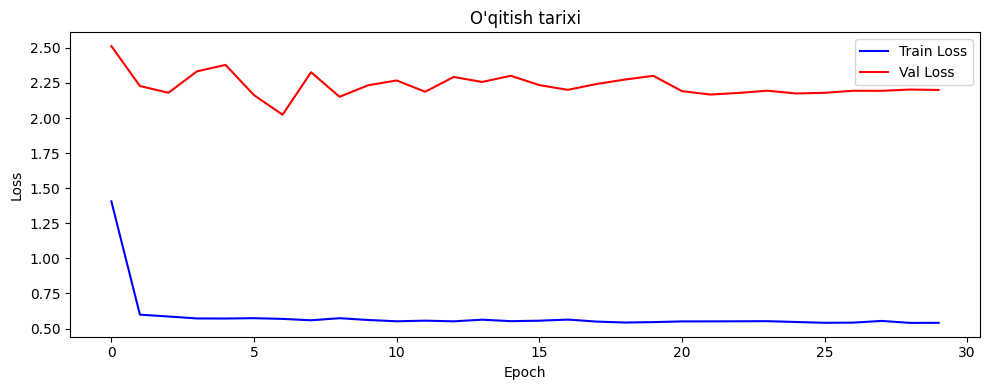

📥 best_model.pt yuklanmoqda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tayyor!


In [10]:
import matplotlib.pyplot as plt
from google.colab import files

# Loss grafigi
plt.figure(figsize=(10,4))
plt.plot(history['train'], label='Train Loss', color='blue')
plt.plot(history['val'],   label='Val Loss',   color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('O\'qitish tarixi')
plt.legend()
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

# Modelni kompyuterga yuklash
print('📥 best_model.pt yuklanmoqda...')
files.download('/content/checkpoints/best_model.pt')
print('✅ Tayyor!')

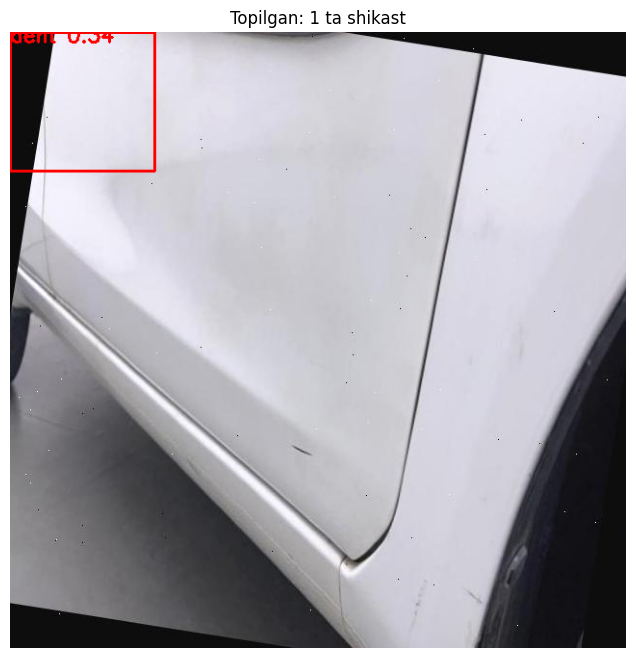

Sinab ko'rildi: ORG_9027695-maruti-maruti_suzuki_ritz_2012-2017_vxi-2015-minor_dent-dents-qvcaziizszakvt__wbutua_jpeg.rf.7d785f720a0fe453c7d0152c82158db4.jpg


In [19]:
import torch, cv2, numpy as np, random, os
import matplotlib.pyplot as plt
from torchvision.ops import nms
import albumentations as A
from albumentations.pytorch import ToTensorV2

CONF_THRESH = 0.3
NMS_THRESH  = 0.45
COLORS = [(255,0,0), (0,255,0), (0,0,255)]

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def predict(img_path, model, device, img_size=640):
    img_orig = cv2.imread(img_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    h0, w0 = img_orig.shape[:2]

    tf = A.Compose([
        A.Resize(height=img_size, width=img_size),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])
    tensor = tf(image=img_orig)['image'].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(tensor)

    ANCHORS = [
        [(10,13),(16,30),(33,23)],
        [(30,61),(62,45),(59,119)],
        [(116,90),(156,198),(373,326)],
    ]
    STRIDES = [8, 16, 32]

    all_boxes = []
    for scale_idx, (pred, anch, stride) in enumerate(zip(preds, ANCHORS, STRIDES)):
        B, C, H, W = pred.shape
        na = 3
        pred_np = pred.cpu().numpy().reshape(B, na, 5 + NUM_CLASSES, H, W)[0]

        for ai, a in enumerate(anch):
            for y in range(H):
                for x in range(W):
                    raw  = pred_np[ai, :, y, x]
                    conf = sigmoid(raw[4])
                    if conf < CONF_THRESH:
                        continue
                    cls_scores = sigmoid(raw[5:])
                    cls_id = cls_scores.argmax()
                    score  = conf * cls_scores[cls_id]
                    if score < CONF_THRESH:
                        continue
                    cx = (sigmoid(raw[0]) + x) * stride / img_size * w0
                    cy = (sigmoid(raw[1]) + y) * stride / img_size * h0
                    bw = np.exp(np.clip(raw[2], -10, 10)) * a[0] / img_size * w0
                    bh = np.exp(np.clip(raw[3], -10, 10)) * a[1] / img_size * h0
                    x1, y1 = max(0, cx - bw/2), max(0, cy - bh/2)
                    x2, y2 = min(w0, cx + bw/2), min(h0, cy + bh/2)
                    all_boxes.append([x1, y1, x2, y2, float(score), int(cls_id)])

    if not all_boxes:
        print('Hech narsa topilmadi.')
        plt.imshow(img_orig)
        plt.axis('off')
        plt.show()
        return

    boxes_t  = torch.tensor([[b[0],b[1],b[2],b[3]] for b in all_boxes], dtype=torch.float32)
    scores_t = torch.tensor([b[4] for b in all_boxes], dtype=torch.float32)
    keep     = nms(boxes_t, scores_t, NMS_THRESH)

    result = img_orig.copy()
    for i in keep:
        b      = all_boxes[i]
        x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[2]), int(b[3])
        cls_id = b[5]
        label  = f'{CLASS_NAMES[cls_id]} {b[4]:.2f}'
        color  = COLORS[cls_id % len(COLORS)]
        cv2.rectangle(result, (x1,y1), (x2,y2), color, 2)
        cv2.putText(result, label, (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(10,8))
    plt.imshow(result)
    plt.axis('off')
    plt.title(f'Topilgan: {len(keep)} ta shikast')
    plt.show()

# Sinash
test_imgs = os.listdir('/content/dataset/images/test')
sample    = random.choice(test_imgs)
predict(f'/content/dataset/images/test/{sample}', model, device)
print(f'Sinab ko\'rildi: {sample}')